# Notebook 5 – Time Series Forecasting

## Objectives

- Load daily earthquake counts
- Explore time series
- Train forecasting model
- Predict future earthquake activity
- Visualize forecasts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [2]:
daily_counts = pd.read_csv(
    "data/processed/earthquake_daily_timeseries.csv"
)

daily_counts.head()

,Date,Earthquake_Count
0,2025-05-04,19
1,2025-05-05,63
2,2025-05-06,59
3,2025-05-07,70
4,2025-05-08,67


In [3]:
daily_counts["Date"] = pd.to_datetime(
    daily_counts["Date"]
)

daily_counts = daily_counts.set_index("Date")

daily_counts.head()

,Earthquake_Count
Date,
2025-05-04,19
2025-05-05,63
2025-05-06,59
2025-05-07,70
2025-05-08,67


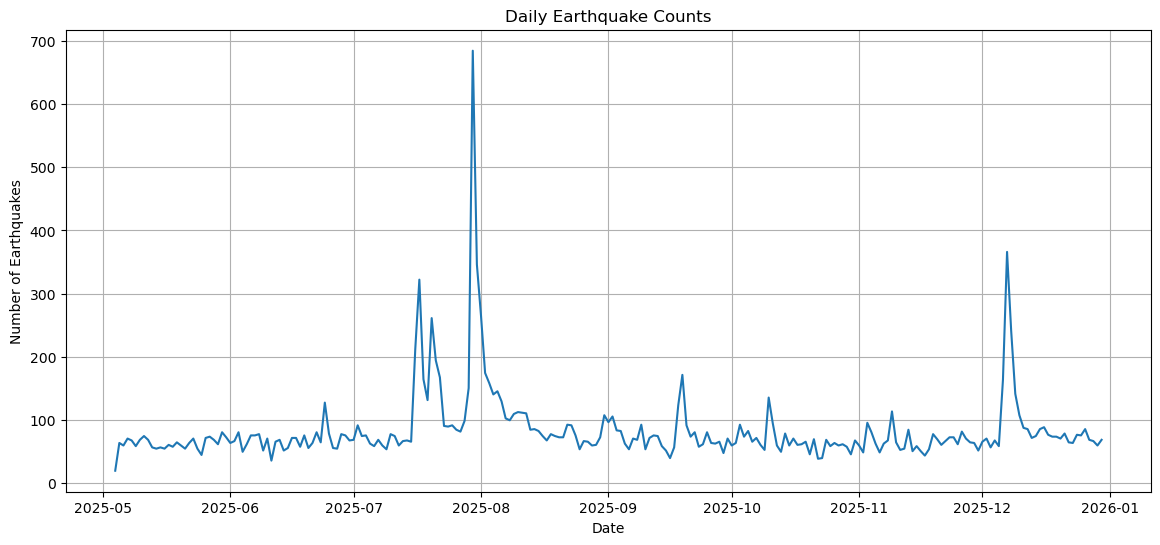

In [4]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_counts.index,
    daily_counts["Earthquake_Count"]
)

plt.title("Daily Earthquake Counts")

plt.xlabel("Date")

plt.ylabel("Number of Earthquakes")

plt.grid(True)

plt.show()

In [5]:
model = ARIMA(
    daily_counts["Earthquake_Count"],
    order=(2,1,2)
)

model_fit = model.fit()

print(model_fit.summary())

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Earthquake_Count   No. Observations:                  241
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1266.786
Date:                Thu, 23 Jul 2026   AIC                           2543.572
Time:                        15:36:43   BIC                           2560.975
Sample:                    05-04-2025   HQIC                          2550.584
                         - 12-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5863      1.433      0.409      0.682      -2.221       3.394
ar.L2         -0.0680      0.735     -0.093      0.926      -1.508       1.372
ma.L1         -0.9686      1.441     -0.672      0.5

In [6]:
forecast = model_fit.forecast(
    steps=30
)

forecast

2025-12-31    74.083124
2026-01-01    77.008082
2026-01-02    78.309054
2026-01-03    78.872786
2026-01-04    79.114779
2026-01-05    79.218301
2026-01-06    79.262530
2026-01-07    79.281417
2026-01-08    79.289481
2026-01-09    79.292924
2026-01-10    79.294394
2026-01-11    79.295022
2026-01-12    79.295289
2026-01-13    79.295404
2026-01-14    79.295453
2026-01-15    79.295473
2026-01-16    79.295482
2026-01-17    79.295486
2026-01-18    79.295488
2026-01-19    79.295488
2026-01-20    79.295489
2026-01-21    79.295489
2026-01-22    79.295489
2026-01-23    79.295489
2026-01-24    79.295489
2026-01-25    79.295489
2026-01-26    79.295489
2026-01-27    79.295489
2026-01-28    79.295489
2026-01-29    79.295489
Freq: D, Name: predicted_mean, dtype: float64

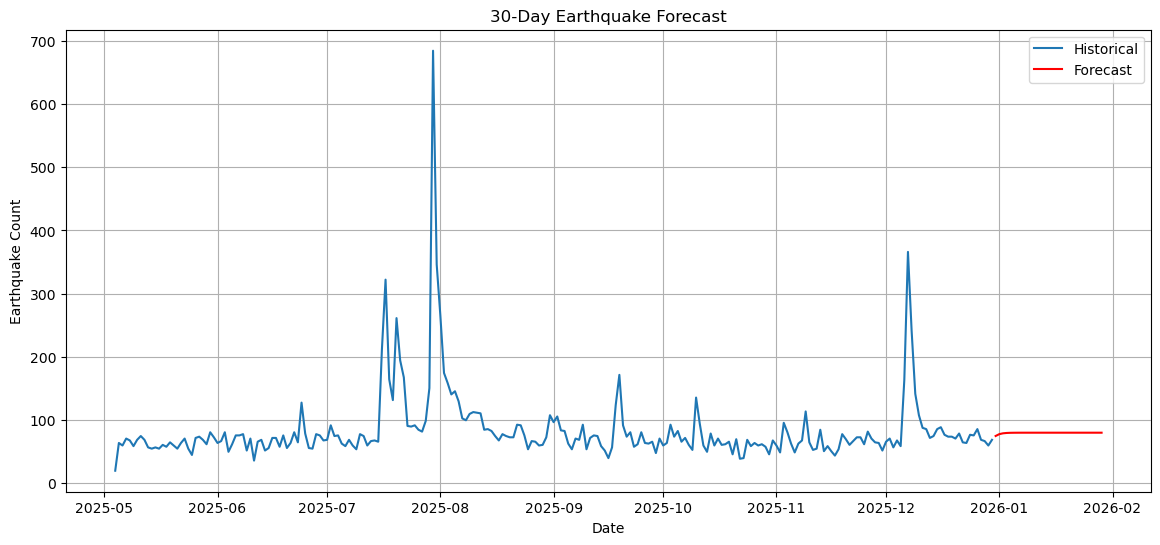

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_counts.index,
    daily_counts["Earthquake_Count"],
    label="Historical"
)

future_dates = pd.date_range(
    start=daily_counts.index[-1] + pd.Timedelta(days=1),
    periods=30
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    label="Forecast"
)

plt.title("30-Day Earthquake Forecast")

plt.xlabel("Date")

plt.ylabel("Earthquake Count")

plt.legend()

plt.grid(True)

plt.show()

In [8]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

forecast_df.to_csv(
    "outputs/forecasts/earthquake_forecast.csv",
    index=False
)

forecast_df.head()

,Date,Forecast
2025-12-31,2025-12-31,74.083124
2026-01-01,2026-01-01,77.008082
2026-01-02,2026-01-02,78.309054
2026-01-03,2026-01-03,78.872786
2026-01-04,2026-01-04,79.114779


In [9]:
print("="*50)
print("Forecast Completed")
print("="*50)
print(f"Forecast Days: {len(forecast_df)}")
print("Results saved to outputs/forecasts/")

Forecast Completed
Forecast Days: 30
Results saved to outputs/forecasts/
